## 03-transformer-block: Experiment 노트북

### 목표
- Scaled Dot-Product Attention에서 $\sqrt{d_k}$의 필요성 검증

### 1. Import 및 설정

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [13]:
import re
import math
import copy
import random
from functools import partial
from typing import Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from attention import scaled_dot_product_attention, MultiHeadAttention
from positional_encoding import SinusoidalPositionalEncoding

### 2. Dot-Product Attention에서 $\sqrt{d_k}$ 스케일링의 효과 확인

In [4]:
torch.manual_seed(42)

batch_size = 64
seq_len = 32
dim_k_values = [8, 32, 128]

for dim_k in dim_k_values:
    query = torch.randn(batch_size, seq_len, dim_k)
    key = torch.randn(batch_size, seq_len, dim_k)

    scores = query @ key.transpose(-1, -2)
    scaled_scores = scores / math.sqrt(dim_k)

    score_std = scores.std(unbiased=False).item()
    scaled_score_std = scaled_scores.std(unbiased=False).item()

    print(
        f"D_k={dim_k:>3} | "
        f"before={score_std:.4f} | "
        f"after={scaled_score_std:.4f}"
    )

    assert abs(scaled_score_std - 1.0) < 0.1

    unscaled_weights = scores.softmax(dim=-1)
    scaled_weights = scaled_scores.softmax(dim=-1)

    # 각 query가 가장 크게 선택한 확률의 평균
    unscaled_max_prob = unscaled_weights.max(dim=-1).values.mean()
    scaled_max_prob = scaled_weights.max(dim=-1).values.mean()

    # 분포의 평균 entropy
    # 평균 entropy = 각 key의 정보량(-log p)을 선택 확률(p)로 가중 평균한 값
    unscaled_entropy = -(
        unscaled_weights
        * unscaled_weights.clamp_min(1e-12).log()
    ).sum(dim=-1).mean()

    scaled_entropy = -(
        scaled_weights
        * scaled_weights.clamp_min(1e-12).log()
    ).sum(dim=-1).mean()

    print(
        f"D_k={dim_k:>3} | "
        f"max prob: {unscaled_max_prob:.4f} → {scaled_max_prob:.4f} | "
        f"entropy: {unscaled_entropy:.4f} → {scaled_entropy:.4f}"
    )

D_k=  8 | before=2.8439 | after=1.0055
D_k=  8 | max prob: 0.4977 → 0.1638 | entropy: 1.6470 → 3.0174
D_k= 32 | before=5.6850 | after=1.0050
D_k= 32 | max prob: 0.7429 → 0.1650 | entropy: 0.7359 → 3.0112
D_k=128 | before=11.3239 | after=1.0009
D_k=128 | max prob: 0.8677 → 0.1655 | entropy: 0.3434 → 3.0099


#### 결과

- `D_k`가 커질수록 scaling을 적용하지 않은 attention score의 표준편차가 증가
  - 그 결과 softmax의 최대 확률은 증가하고 entropy는 감소하여 분포가 한 key에 포화된 것을 확인
  - softmax의 최대 확률이 증가한다는 것은, 확률분포가 더욱 뾰족해지는 것으로 볼 수 있므며, 따라서 모든 토큰을 골고루 보지 않고 one-hot과 같은 형태로 토큰을 보게 되어 attention의 가치가 떨어진다.
- 반면 `1 / sqrt(D_k)` scaling을 적용하면 score의 표준편차가 약 1로 유지됐으며, 최대 확률과 entropy도 `D_k`와 관계없이 안정적으로 유지됨

### 3. Sinusoidal Positional Encoding 확인
- Self-attention은 입력 순서를 알지 못함
- 각 Token embedding에 Positional Encoding을 통해서 위치 신호를 주입
- Sinusoidal 방식은 
  1) Learnable Parameter가 필요 없으며, 
  2) 위치마다 서로 다른 표현을 생성하고, 
  3) 상대적인 거리 표현이 비교적 쉬우며, 
  4) 외삽의 계산 가능성이라는 장점을 가지고 있음

$$
PE(pos, 2i) = \sin(\frac{pos}{10000^{2i/d}})
$$
$$
PE(pos, 2i) = \cos(\frac{pos}{10000^{2i/d}})
$$

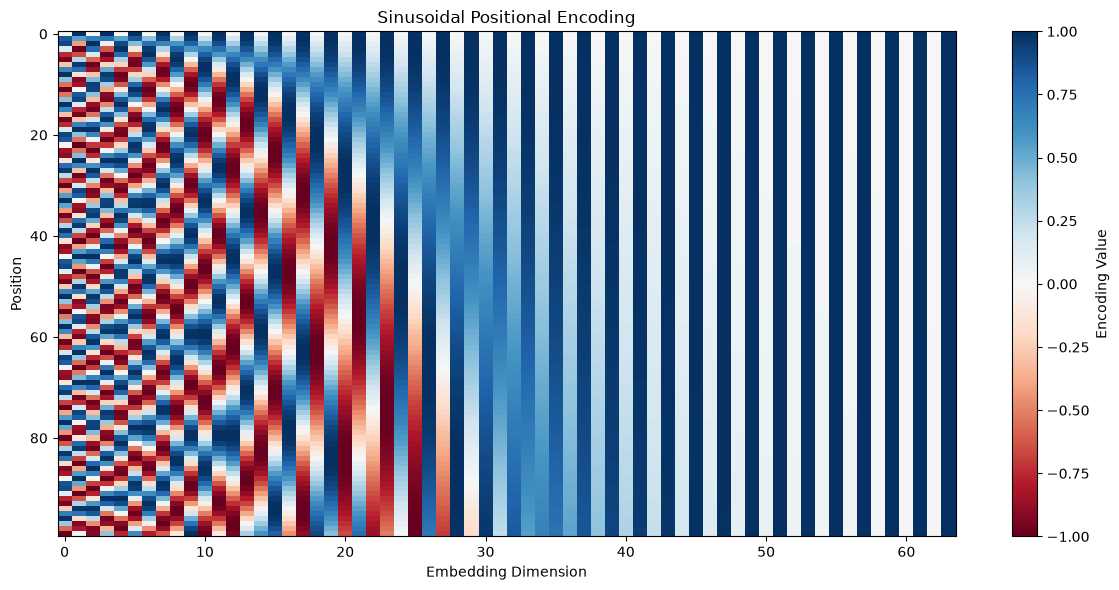

In [12]:
d_model = 64
max_seq_len = 100

positional_encoding = SinusoidalPositionalEncoding(
    d_model=d_model,
    max_seq_len=max_seq_len,
)
pe = positional_encoding.pe[0].cpu()  # (position, dimension)

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(
    pe,
    aspect="auto",
    cmap="RdBu",
    vmin=-1,
    vmax=1,
)

ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Position")
ax.set_title("Sinusoidal Positional Encoding")
fig.colorbar(image, ax=ax, label="Encoding Value")

plt.tight_layout()
plt.show()

#### 결과

- (pos, emb_dim)에 따라서 -1.0~1.0까지의 Positional Encoding 값 변화를 확인할 수 있다.
- 낮은 Embedding dimension에서는 주기($10000^{2i/d}$)가 짧아 가까운 거리의 위치 변화를 표현하고,
- 높은 Embedding dimension에서는 주기가 길어 넓은 범위의 위치 변화를 표현할 수 있다.

특히 높은 dim에서는 주기가 매우 길어지기 때문에, sin/cos에 들어가는 각도가 매우 작아지게 된다.
따라서 작은 각도에서는 sin(x)≈0, cos(x)≈1이므로 0, 1이 번갈아서 등장하게 된다.

### 4. Positional Encoding 유무에 따른 Multi-head Attention Weight 변화

In [17]:
torch.manual_seed(42)

batch_size = 1
seq_len = 16
d_model = 64
num_heads = 4

token = torch.randn(batch_size, 1, d_model)
tokens = token.expand(batch_size, seq_len, d_model).clone()

multi_head_attention = MultiHeadAttention(d_model, num_heads)
positional_encoding = SinusoidalPositionalEncoding(d_model, seq_len)

without_pe_output, without_pe_weights = multi_head_attention(
    tokens,
    tokens,
    tokens,
)

tokens_with_pe = positional_encoding(tokens)
with_pe_output, with_pe_weights = multi_head_attention(
    tokens_with_pe,
    tokens_with_pe,
    tokens_with_pe,
)

assert without_pe_weights.shape == (
    batch_size,
    num_heads,
    seq_len,
    seq_len,
)
assert with_pe_weights.shape == without_pe_weights.shape

uniform_weights = torch.full_like(
    without_pe_weights,
    1 / seq_len,
)

torch.testing.assert_close(
    without_pe_weights,
    uniform_weights,
)
assert not torch.allclose(
    with_pe_weights,
    uniform_weights,
)

print(
    "Without PE deviation:",
    (without_pe_weights - uniform_weights).abs().max().item(),
)
print(
    "With PE deviation:",
    (with_pe_weights - uniform_weights).abs().max().item(),
)

Without PE deviation: 0.0
With PE deviation: 0.042494818568229675


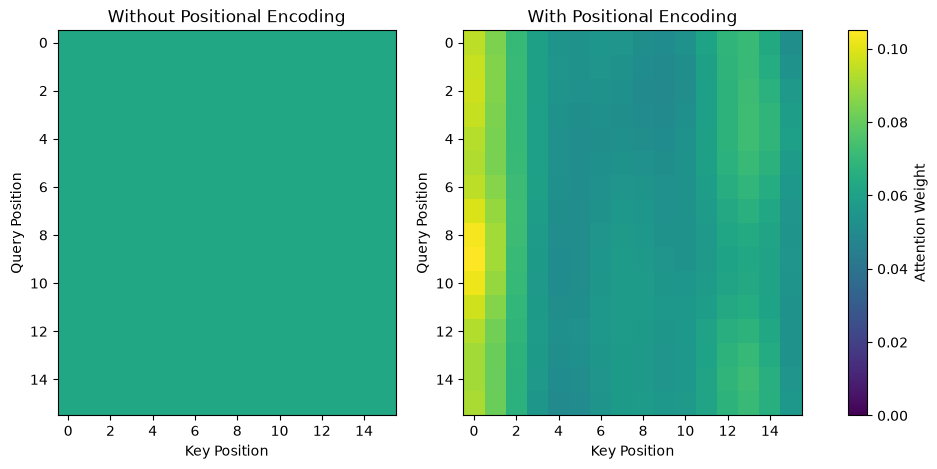

In [18]:
without_pe_map = without_pe_weights[0, 0].detach().cpu()
with_pe_map = with_pe_weights[0, 0].detach().cpu()

vmax = max(
    without_pe_map.max().item(),
    with_pe_map.max().item(),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

images = []
for ax, attention_map, title in zip(
    axes,
    [without_pe_map, with_pe_map],
    ["Without Positional Encoding", "With Positional Encoding"],
):
    image = ax.imshow(
        attention_map,
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=vmax,
    )
    images.append(image)
    ax.set_xlabel("Key Position")
    ax.set_ylabel("Query Position")
    ax.set_title(title)

fig.colorbar(images[0], ax=axes, label="Attention Weight")
plt.show()